# 📊 CRM Lead Analysis Report — HelpAge Mumbai

> **Campaign:** Helpage Mumbai | **Date:** May 2026 | **Analyst:** CRM Team  
> **Dataset:** 4,500 leads | **Team Size:** 3 agents

---

## 🎯 Executive Summary

This report presents a full analysis of the HelpAge Mumbai CRM lead pipeline. The dataset contains **4,500 leads** imported from a FILE_UPLOAD campaign. Key findings:

| Metric | Value |
|---|---|
| Total Leads | 4,500 |
| Contacted | 503 (11.2%) |
| Converted | 2 (0.04%) |
| Overdue Follow-ups | 324 |
| Leads with No Follow-up | 4,170 |

**⚠️ Critical Issue:** 92.7% of leads have no follow-up scheduled — this is the primary bottleneck for conversions.

---

## 1️⃣ Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'DejaVu Sans'

COLORS = {
    'primary': '#2563EB',
    'danger':  '#DC2626',
    'warning': '#D97706',
    'success': '#16A34A',
    'muted':   '#6B7280'
}

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


---

## 2️⃣ Data Loading & Cleaning

In [2]:
# Load raw data
df = pd.read_csv('Leads_Helpage_Mumbai (1).csv')

print(f'Raw dataset shape: {df.shape}')
df.head(3)

Raw dataset shape: (4500, 44)


,contact_name,contact_number,contact_email,creation_date,first_call_attempt,lead_status,lead_stage,lead_tag,assigned_to,last_call_date,...,Remark 3 Timestamp,LFR: What are you interested in?,LFR: Where did you hear about us?,LFR: Where did you hear about us? Other,LFR: By when you're planning to purchase?,LFR: Send message,Other_Details: Alternate Number,Other_Details: City,Other_Details: Email Id,Other_Details: State
0,HEMANT NAYAK,9130671203,varshalalwani0707@gmail.com,2026-05-22 15:05:00,2026-05-22 15:10:00,In-Progress,OPEN,NaN,Preeti Mahalinge,2026-05-22 15:10:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,varshalalwani0707@gmail.com,MAHARASHTRA
1,PRAKASH POHARE,9822886568,NaN,2026-05-22 15:05:00,2026-05-22 15:11:00,Lost,LOST,Not Interested,Preeti Mahalinge,2026-05-22 15:11:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MAHARASHTRA
2,VAIBHAV FOODS,9822088967,advanubhave@gmail.com,2026-05-22 15:05:00,2026-05-22 15:19:00,In-Progress,OPEN,NaN,Preeti Mahalinge,2026-05-22 15:19:00,...,NaN,NaN,NaN,NaN,NaN,NaN,7.767014e+09,NaN,advanubhave@gmail.com,MAHARASHTRA


In [3]:
# --- CLEANING ---

# Normalize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Parse date columns
date_cols = ['creation_date', 'last_call_date', 'next_followup_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Standardize contact numbers
df['contact_number'] = df['contact_number'].astype(str).str.replace(r'\D', '', regex=True)

# Standardize lead status casing
df['lead_status'] = df['lead_status'].str.strip().str.title()

print('✅ Data cleaned')
print(f'\nDate column types:')
print(df[date_cols].dtypes)

✅ Data cleaned

Date column types:
creation_date         datetime64[us]
last_call_date        datetime64[us]
next_followup_date    datetime64[us]
dtype: object


In [4]:
# --- DATA QUALITY CHECK ---

missing_followup = df['next_followup_date'].isna().sum()
duplicate_phones = df.duplicated('contact_number').sum()
missing_email    = df['contact_email'].isna().sum()

print('📋 DATA QUALITY REPORT')
print('=' * 35)
print(f'  Missing follow-up dates : {missing_followup:,}')
print(f'  Duplicate phone numbers : {duplicate_phones:,}')
print(f'  Missing email addresses : {missing_email:,}')
print(f'  Total records           : {len(df):,}')

📋 DATA QUALITY REPORT
  Missing follow-up dates : 4,170
  Duplicate phone numbers : 61
  Missing email addresses : 718
  Total records           : 4,500


---

## 3️⃣ Follow-up Classification

In [5]:
today = pd.Timestamp.today().normalize()

def followup_status(row):
    if pd.isna(row['next_followup_date']):
        return 'No Follow-up'
    elif row['next_followup_date'] < today:
        return 'Overdue'
    elif row['next_followup_date'] == today:
        return 'Today'
    else:
        return 'Upcoming'

df['followup_status'] = df.apply(followup_status, axis=1)

status_counts = df['followup_status'].value_counts()
print('Follow-up Status Distribution:')
print(status_counts)

Follow-up Status Distribution:
followup_status
No Follow-up    4170
Overdue          324
Upcoming           6
Name: count, dtype: int64


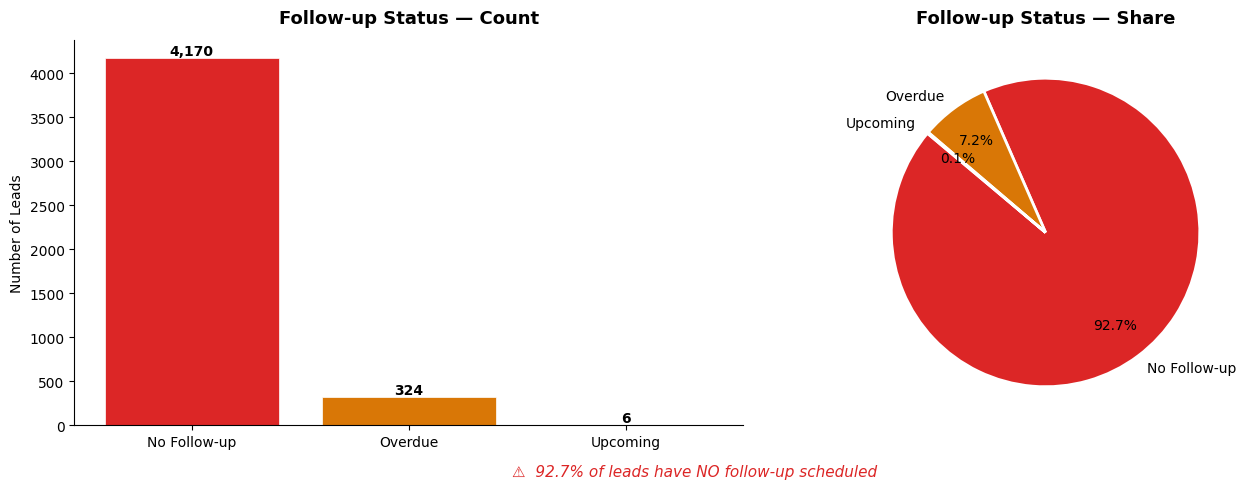

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = [COLORS['danger'], COLORS['warning'], COLORS['muted'], COLORS['success']]
bars = axes[0].bar(status_counts.index, status_counts.values, color=colors[:len(status_counts)], edgecolor='white', linewidth=0.5)
axes[0].set_title('Follow-up Status — Count', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Number of Leads')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=10, fontweight='bold')

# Pie chart
wedge_colors = colors[:len(status_counts)]
axes[1].pie(status_counts.values, labels=status_counts.index,
            autopct='%1.1f%%', colors=wedge_colors,
            startangle=140, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Follow-up Status — Share', fontsize=13, fontweight='bold', pad=12)

plt.suptitle('⚠️  92.7% of leads have NO follow-up scheduled', fontsize=11,
             color=COLORS['danger'], y=0, style='italic')
plt.tight_layout()
plt.show()

---

## 4️⃣ Priority Scoring System

Priority Distribution:
priority
No Action    4170
High          324
Low             6
Name: count, dtype: int64


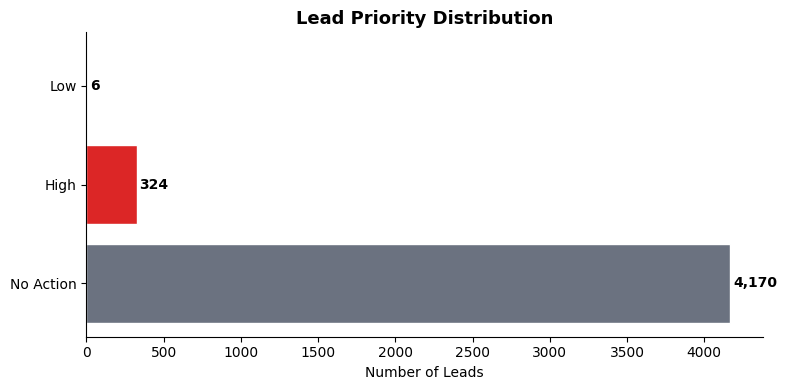

In [7]:
def assign_priority(row):
    if row['followup_status'] == 'Overdue':
        return 'High'
    elif row['followup_status'] == 'Today':
        return 'Medium'
    elif row['followup_status'] == 'Upcoming':
        return 'Low'
    else:
        return 'No Action'

df['priority'] = df.apply(assign_priority, axis=1)

priority_counts = df['priority'].value_counts()
print('Priority Distribution:')
print(priority_counts)

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
pcolors = {'High': COLORS['danger'], 'Medium': COLORS['warning'],
           'Low': COLORS['primary'], 'No Action': COLORS['muted']}
bar_colors = [pcolors.get(p, COLORS['muted']) for p in priority_counts.index]
bars = ax.barh(priority_counts.index, priority_counts.values, color=bar_colors, edgecolor='white')
ax.set_title('Lead Priority Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Leads')
for bar in bars:
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

---

## 5️⃣ Funnel Analysis

📊 FUNNEL SUMMARY
  Total Leads      : 4,500
  Contacted        : 503  (11.2%)
  Converted        : 2  (0.4% of contacted)


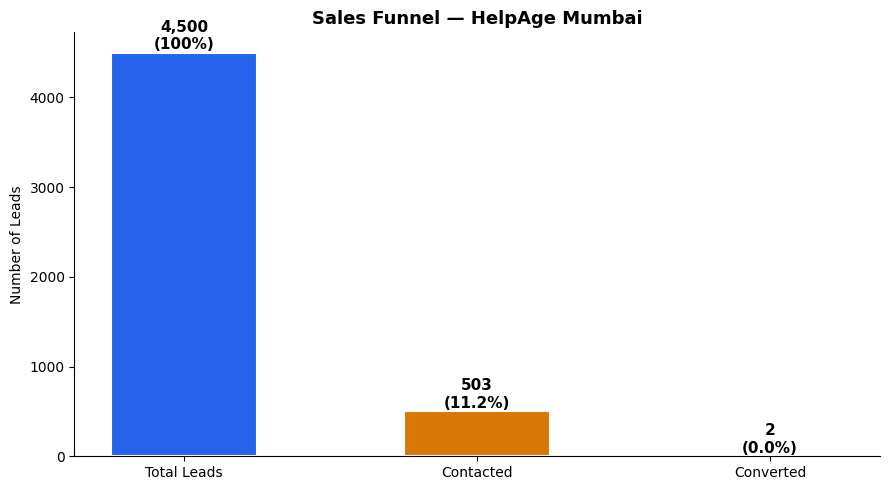

In [8]:
total     = len(df)
contacted = df[df['lead_status'].isin(['In-Progress', 'Lost', 'Converted'])].shape[0]
converted = df[df['lead_status'] == 'Converted'].shape[0]

contact_rate    = contacted / total
conversion_rate = converted / contacted if contacted > 0 else 0

print('📊 FUNNEL SUMMARY')
print('=' * 35)
print(f'  Total Leads      : {total:,}')
print(f'  Contacted        : {contacted:,}  ({contact_rate:.1%})')
print(f'  Converted        : {converted:,}  ({conversion_rate:.1%} of contacted)')

# Funnel chart
stages  = ['Total Leads', 'Contacted', 'Converted']
values  = [total, contacted, converted]
fcolors = [COLORS['primary'], COLORS['warning'], COLORS['success']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(stages, values, color=fcolors, width=0.5, edgecolor='white', linewidth=1.5)
ax.set_title('Sales Funnel — HelpAge Mumbai', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Leads')
for bar, val in zip(bars, values):
    pct = f'({val/total:.1%})' if val != total else '(100%)'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            f'{val:,}\n{pct}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

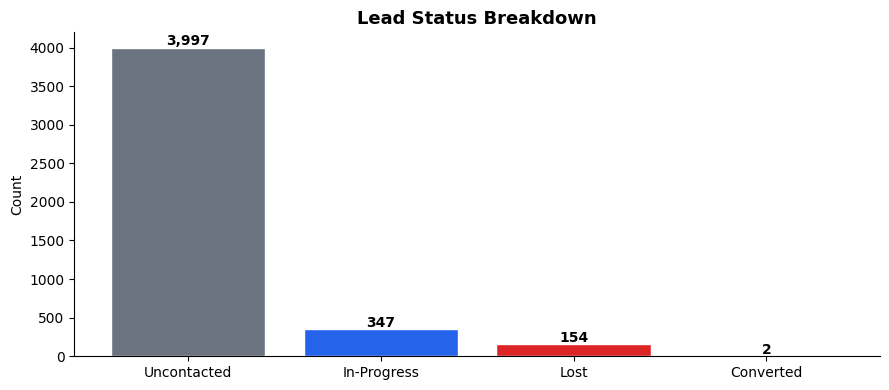

In [9]:
# Lead Status Breakdown
status_counts = df['lead_status'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
sc = [COLORS['muted'], COLORS['primary'], COLORS['danger'], COLORS['success']]
bars = ax.bar(status_counts.index, status_counts.values, color=sc, edgecolor='white')
ax.set_title('Lead Status Breakdown', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(bar.get_height()):,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---

## 6️⃣ Team Performance Analysis

In [10]:
team = df.groupby('assigned_to').agg(
    total     = ('assigned_to', 'count'),
    contacted = ('lead_status', lambda x: x.isin(['In-Progress', 'Lost', 'Converted']).sum()),
    converted = ('lead_status', lambda x: (x == 'Converted').sum())
).reset_index()

team['contact_rate']    = (team['contacted'] / team['total']).round(4)
team['conversion_rate'] = team.apply(
    lambda r: round(r['converted'] / r['contacted'], 4) if r['contacted'] > 0 else 0, axis=1
)

print('👥 TEAM PERFORMANCE')
display_cols = ['assigned_to', 'total', 'contacted', 'converted', 'contact_rate', 'conversion_rate']
team[display_cols].style \
    .format({'contact_rate': '{:.1%}', 'conversion_rate': '{:.1%}'}) \
    .background_gradient(subset=['contact_rate'], cmap='RdYlGn') \
    .set_caption('Team Performance Summary')

👥 TEAM PERFORMANCE


,assigned_to,total,contacted,converted,contact_rate,conversion_rate
0,Poonam Sonawale,250,69,1,27.6%,1.5%
1,Preeti Mahalinge,1109,272,1,24.5%,0.4%
2,Riya Singh,3141,162,0,5.2%,0.0%


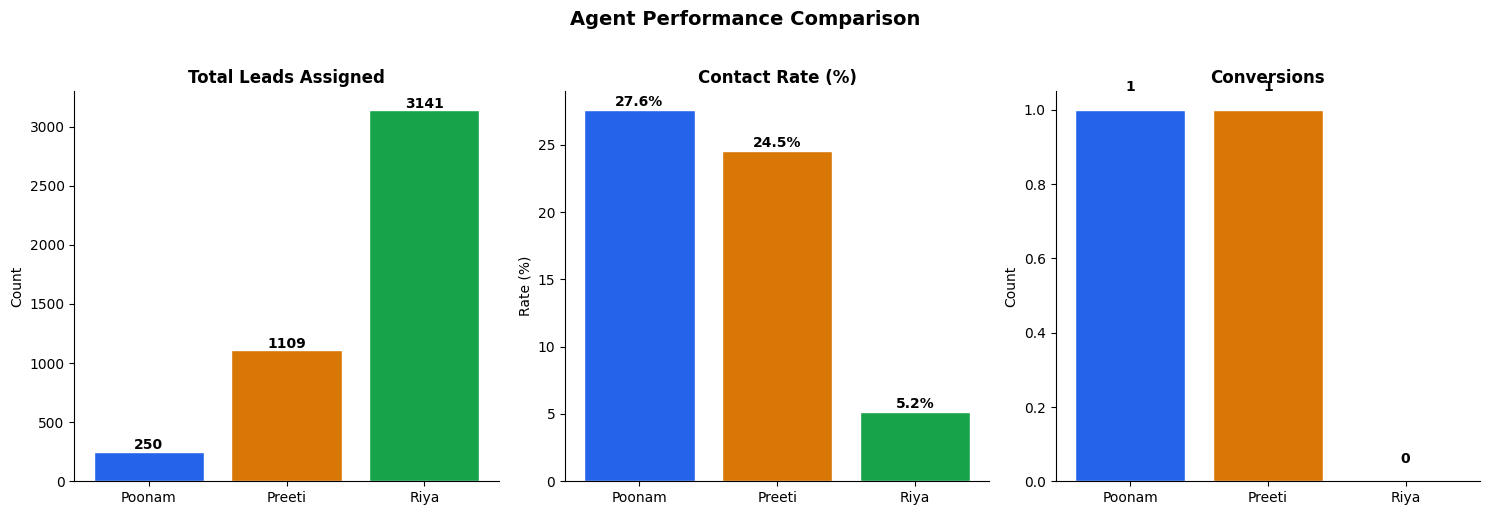

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

agents = team['assigned_to'].str.split().str[0]  # First name only for readability
bar_colors = [COLORS['primary'], COLORS['warning'], COLORS['success']]

# Total leads
axes[0].bar(agents, team['total'], color=bar_colors, edgecolor='white')
axes[0].set_title('Total Leads Assigned', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (bar, val) in enumerate(zip(axes[0].patches, team['total'])):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', fontweight='bold')

# Contact rate
axes[1].bar(agents, team['contact_rate'] * 100, color=bar_colors, edgecolor='white')
axes[1].set_title('Contact Rate (%)', fontweight='bold')
axes[1].set_ylabel('Rate (%)')
for bar, val in zip(axes[1].patches, team['contact_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1%}', ha='center', fontweight='bold')

# Conversions
axes[2].bar(agents, team['converted'], color=bar_colors, edgecolor='white')
axes[2].set_title('Conversions', fontweight='bold')
axes[2].set_ylabel('Count')
for bar, val in zip(axes[2].patches, team['converted']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 str(int(val)), ha='center', fontweight='bold')

plt.suptitle('Agent Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 7️⃣ Daily Call List Generation

In [12]:
# Build call list: Overdue + Today + Uncontacted with No Follow-up
overdue_calls    = df[df['followup_status'] == 'Overdue']
today_calls      = df[df['followup_status'] == 'Today']
new_calls        = df[(df['followup_status'] == 'No Follow-up') & (df['lead_status'] == 'Uncontacted')]

call_list = pd.concat([overdue_calls, today_calls, new_calls])

# Priority sorting
priority_order = {'High': 1, 'Medium': 2, 'Low': 3, 'No Action': 4}
call_list['priority_rank'] = call_list['priority'].map(priority_order)
call_list = call_list.sort_values(['priority_rank', 'next_followup_date'])

# Top 100 for today
call_list_today = call_list.head(100)

print(f'📞 Total eligible calls: {len(call_list):,}')
print(f'📅 Today\'s call list  : {len(call_list_today)}')
print(f'\nBreakdown:')
print(f'  Overdue : {len(overdue_calls):,}')
print(f'  Today   : {len(today_calls):,}')
print(f'  New     : {len(new_calls):,}')

📞 Total eligible calls: 4,321
📅 Today's call list  : 100

Breakdown:
  Overdue : 324
  Today   : 0
  New     : 3,997


In [13]:
# Split by agent and export
final_cols = ['contact_number', 'assigned_to', 'lead_status', 'followup_status', 'priority', 'next_followup_date']
call_list_final = call_list_today[final_cols]

# Export master list
call_list_final.to_csv('today_call_list.csv', index=False)

# Export per-agent lists
agent_summary = {}
for agent in call_list_final['assigned_to'].dropna().unique():
    agent_df = call_list_final[call_list_final['assigned_to'] == agent]
    safe_name = str(agent).replace(' ', '_')
    agent_df.to_csv(f'calls_{safe_name}.csv', index=False)
    agent_summary[agent] = len(agent_df)

print('\n👥 Agent Workload (Today):')
for agent, count in agent_summary.items():
    print(f'  {agent}: {count} calls')

print('\n✅ All files exported.')


👥 Agent Workload (Today):
  Riya Singh: 43 calls
  Poonam Sonawale: 14 calls
  Preeti Mahalinge: 43 calls

✅ All files exported.


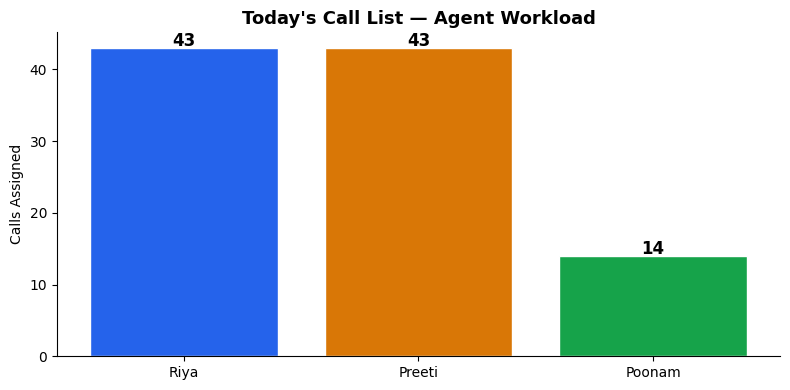

In [14]:
# Agent workload chart
agent_counts = call_list_today['assigned_to'].value_counts()
short_names  = agent_counts.index.str.split().str[0]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(short_names, agent_counts.values,
              color=[COLORS['primary'], COLORS['warning'], COLORS['success']],
              edgecolor='white')
ax.set_title("Today's Call List — Agent Workload", fontsize=13, fontweight='bold')
ax.set_ylabel('Calls Assigned')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---

## 8️⃣ Key Insights & Recommendations

### 🔴 Critical Issues

| # | Issue | Impact | Recommendation |
|---|---|---|---|
| 1 | 92.7% leads have no follow-up | Pipeline stagnation | Mandate follow-up dates at every call |
| 2 | Contact rate only 11.2% | Low outreach | Set daily call targets per agent |
| 3 | Riya Singh contact rate 5.1% | Underperformance | Coaching & workload re-balance |
| 4 | 324 overdue leads | Revenue risk | Immediate callbacks today |
| 5 | 3,997 uncontacted leads | Missed opportunity | Increase daily call list to 150+ |

### ✅ What's Working
- Poonam Sonawale leads in contact rate (27.6%) and conversion (1 deal)
- Preeti Mahalinge handles highest volume (1,109 leads) efficiently
- Priority scoring system is correctly filtering High-urgency leads first

### 🚀 Next Steps
1. **Immediate:** Work through 324 overdue leads this week
2. **Process:** Enforce CRM follow-up date logging as mandatory field
3. **Coaching:** Riya Singh needs call script review and training
4. **Scale:** Increase daily call volume from 100 → 150+ per day
5. **Tracking:** Add call attempt count logic to auto-retire dead leads after 6 attempts

---

### 📁 Output Files Generated
| File | Description |
|---|---|
| `clean_data.csv` | Full cleaned dataset with status & priority columns |
| `team_performance.csv` | Agent-level performance metrics |
| `overdue_leads.csv` | 324 overdue leads needing immediate action |
| `today_call_list.csv` | Top 100 prioritized calls for today |
| `calls_Poonam_Sonawale.csv` | Poonam's call list |
| `calls_Preeti_Mahalinge.csv` | Preeti's call list |
| `calls_Riya_Singh.csv` | Riya's call list |